## Dawn Andrei Pamesa
## TS31

Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import r2_score

Loading the Dataset

In [2]:
df = pd.read_csv("real_estate_taiwan-2.csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


Select Features

In [3]:
X = df[["X2 house age", "X3 distance to the nearest MRT station"]]
y = df["Y house price of unit area"]

Check Missing Features

In [4]:
print(df.isnull().sum())
display(df[df.isnull().any(axis=1)])

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area


Imputing and Scaling

In [5]:
X = X.fillna(X.mean())

In [6]:
for column in X.select_dtypes(include=["object", "category"]).columns:
    X[column] = X[column].fillna(X[column].mode()[0])

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Splitting the Data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 310
Testing rows: 104


Plotting of Correlations

In [9]:
selected_data = df[["X2 house age", "X3 distance to the nearest MRT station", "Y house price of unit area"]]

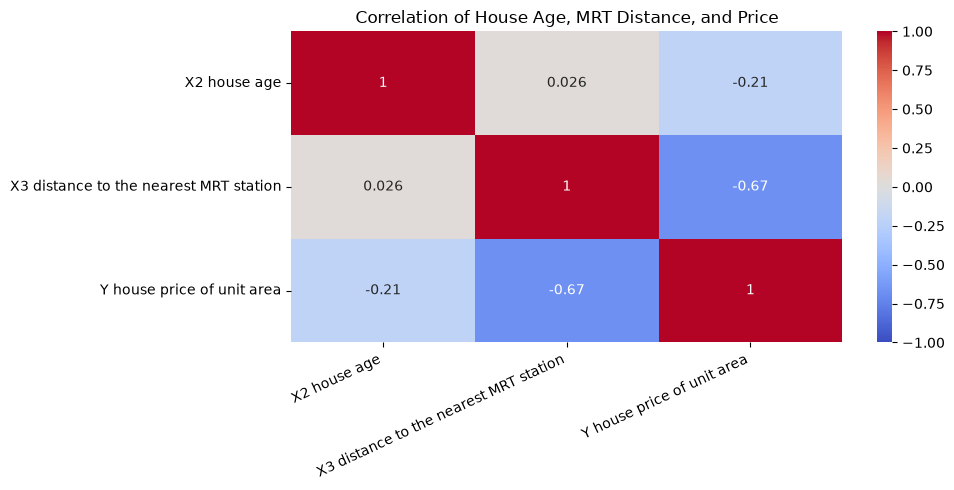

In [10]:
plt.figure(figsize=(10, 5))
sns.heatmap(selected_data.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of House Age, MRT Distance, and Price")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Training Multiple Linear Regression Model

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[-2.63,-9.32]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,38.41
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[17.82,16.88]"


Predicting and Reporting R²

In [12]:
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

print("Training R²:", round(r2_score(y_train, y_pred_train), 4))
print("Testing R²:", round(r2_score(y_test, y_pred_test), 4))

Training R²: 0.4841
Testing R²: 0.4879


Predicting using New Data

In [13]:
new_data = pd.DataFrame({
    "X2 house age": [20],
    "X3 distance to the nearest MRT station": [500]
})

new_data_scaled = scaler.transform(new_data)
new_pred = lr.predict(new_data_scaled)

print("Predicted house price per unit area:", round(new_pred[0], 2))

Predicted house price per unit area: 42.2


Choosing the Alpha for Ridge Regression

In [14]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

In [15]:
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

print("Best Ridge alpha :", ridge_cv.alpha_)

Best Ridge alpha : 10.0


Training Ridge Regression Model

In [16]:
ridge = Ridge(alpha=ridge_cv.alpha_)
ridge.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",np.float64(10.0)
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sa

Predicting and Reporting R² for Ridge Regression

In [17]:
y_pred_train_ridge = ridge.predict(X_train)
y_pred_test_ridge = ridge.predict(X_test)

print("Ridge Training R² :", round(r2_score(y_train, y_pred_train_ridge), 4))
print("Ridge Testing R²  :", round(r2_score(y_test, y_pred_test_ridge), 4))

Ridge Training R² : 0.4836
Ridge Testing R²  : 0.4905


Choosing the Alpha for Lasso Regression

In [18]:
lasso_cv = LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10], cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)

print("Best Lasso alpha :", lasso_cv.alpha_)

Best Lasso alpha : 0.01


Training Lasso Regression Model

In [19]:
lasso = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",np.float64(0.01)
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


Predicting and Reporting R² for Lasso Regression

In [20]:
y_pred_train_lasso = lasso.predict(X_train)
y_pred_test_lasso = lasso.predict(X_test)

print("Lasso Training R² :", round(r2_score(y_train, y_pred_train_lasso), 4))
print("Lasso Testing R²  :", round(r2_score(y_test, y_pred_test_lasso), 4))

Lasso Training R² : 0.4841
Lasso Testing R²  : 0.488


Comparing the Three Models

In [21]:
results = pd.DataFrame({
    "Model": ["Multiple Linear Regression", "Ridge Regression", "Lasso Regression"],
    "Training R²": [r2_score(y_train, y_pred_train), r2_score(y_train, y_pred_train_ridge), r2_score(y_train, y_pred_train_lasso)],
    "Testing R²": [r2_score(y_test, y_pred_test), r2_score(y_test, y_pred_test_ridge), r2_score(y_test, y_pred_test_lasso)],
}).round(4)

results

,Model,Training R²,Testing R²
0,Multiple Linear Regression,0.4841,0.4879
1,Ridge Regression,0.4836,0.4905
2,Lasso Regression,0.4841,0.4880


Coefficients of the Three Models

In [22]:
coefficients = pd.DataFrame({
    "Feature": ["X2 house age", "X3 distance to the nearest MRT station"],
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
}).round(4)

coefficients

,Feature,Linear,Ridge,Lasso
0,X2 house age,-2.6283,-2.5600,-2.6187
1,X3 distance to the nearest MRT station,-9.3172,-9.0173,-9.3072


## Conclusion

All three models explain about half of the variation in house price, and none is clearly better. Multiple linear regression scored 0.4841 on the training set and 0.4879 on the test set. Ridge regression with an alpha of 10 scored 0.4836 and 0.4905. Lasso regression with an alpha of 0.01 scored 0.4841 and 0.4880. Ridge has the highest testing R², but its lead over linear regression is only 0.0026, which is too small to call a real improvement.

The training and testing scores are almost the same in every model, so the models are not overfitting. That is why Ridge and Lasso change so little: with only two features and 310 training rows, there is no overfitting for the penalty to fix. The coefficients show the same thing. Ridge shrinks them slightly (house age goes from -2.6283 to -2.5600), and Lasso keeps both features with almost no change.

The limit on accuracy comes from the features, not the algorithm. House age and distance to the nearest MRT station leave about half of the price variation unexplained, so a stronger result would need the other columns, such as the number of convenience stores and the location. For this problem, plain multiple linear regression is the simplest choice, and Ridge is the better choice only if a small gain on the test set matters.